In [50]:
#!pip install nixtla

In [4]:
import pandas as pd
from nixtla import NixtlaClient
nixtla_client = NixtlaClient(api_key = 'nixak-fdeb395c1c38014d4292173c77382d77112264957706fd4bfd4ba3ea8d27da243ee0fa406f4a8105')
nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

In [5]:
## Load the data from file/files

In [6]:
#load data from cities

# 2. Read historic electricity demand data
df = pd.read_csv('polandia_hourly.csv')
#df = pd.read_csv('fromCale/daily_data_pl.csv')
df

,utc_timestamp,PL_load_actual_entsoe_transparency
0,2015-01-01 00:00:00,15557.0
1,2015-01-01 01:00:00,14727.0
2,2015-01-01 02:00:00,13979.0
3,2015-01-01 03:00:00,13454.0
4,2015-01-01 04:00:00,13306.0
...,...,...
43819,2019-12-31 19:00:00,18115.0
43820,2019-12-31 20:00:00,16998.0
43821,2019-12-31 21:00:00,16239.0
43822,2019-12-31 22:00:00,15784.0


## Select training data based on Scenario

In [7]:
# Select data for training # 
fra = '2018-01-01'
til = '2018-11-01'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
trainData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
trainData

,utc_timestamp,PL_load_actual_entsoe_transparency
26304,2018-01-01 00:00:00,14979.0
26305,2018-01-01 01:00:00,14398.0
26306,2018-01-01 02:00:00,13789.0
26307,2018-01-01 03:00:00,13434.0
26308,2018-01-01 04:00:00,13285.0
...,...,...
33595,2018-10-31 19:00:00,23122.0
33596,2018-10-31 20:00:00,22152.0
33597,2018-10-31 21:00:00,20445.0
33598,2018-10-31 22:00:00,18358.0


In [8]:
len(trainData)

7296

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


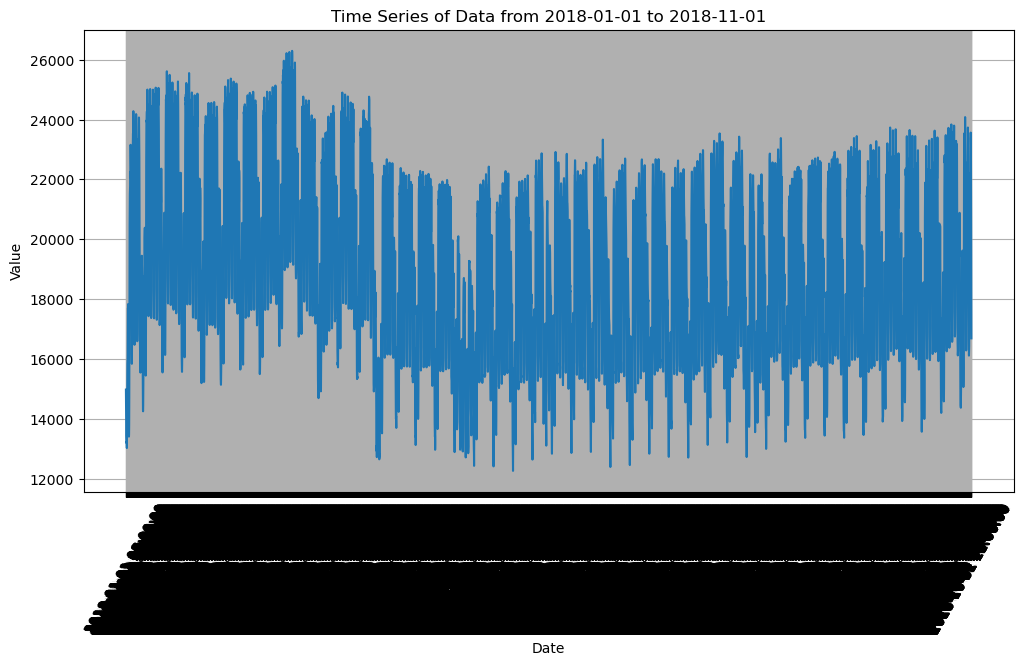

In [9]:
# Basic time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(trainData['utc_timestamp'], trainData['PL_load_actual_entsoe_transparency'])
plt.title(f'Time Series of Data from {fra} to {til}')
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Value')
plt.grid(True)
plt.show()

## Validation data selection based on scenario

In [10]:
# Select data for validation # 
fra = '2018-11-01'
til = '2018-12-01'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
validData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
validData = validData.rename(columns={'utc_timestamp': 'ds', 'PL_load_actual_entsoe_transparency': 'actual'})
validData

,ds,actual
33600,2018-11-01 00:00:00,15637.0
33601,2018-11-01 01:00:00,15051.0
33602,2018-11-01 02:00:00,14659.0
33603,2018-11-01 03:00:00,14480.0
33604,2018-11-01 04:00:00,14534.0
...,...,...
34315,2018-11-30 19:00:00,25057.0
34316,2018-11-30 20:00:00,24284.0
34317,2018-11-30 21:00:00,22870.0
34318,2018-11-30 22:00:00,21467.0


In [11]:
len(validData)

720

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


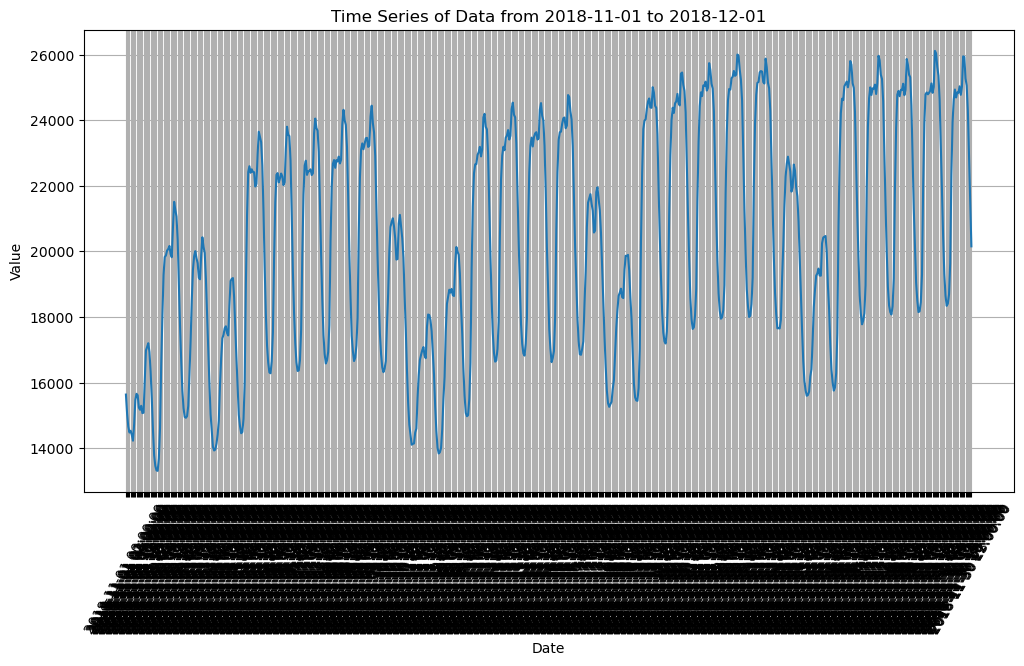

In [12]:
# Basic time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(validData['ds'], validData['actual'])
plt.title(f'Time Series of Data from {fra} to {til}')
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
   
plt.ylabel('Value')
plt.grid(True)
plt.show()


## Forcasting wsith timeGPT

In [13]:
# 3. Forecast the next 24 hours
# First, ensure your DataFrame has the required column names
# Nixtla typically expects 'ds' for the timestamp column and 'y' for the target variable

# Assuming trainData has a datetime column with a different name (e.g., 'date' or 'timestamp')
# Rename it to match Nixtla's expected format
trainData = trainData.rename(columns={'utc_timestamp': 'ds', 'PL_load_actual_entsoe_transparency': 'y'})

# Now try forecasting again
fcst_df = nixtla_client.forecast(trainData, 
                                 h=len(validData), 
                                 freq='H',
                                 model='timegpt-1-long-horizon')

INFO:nixtla.nixtla_client:Validating inputs...
/opt/anaconda3/lib/python3.13/site-packages/utilsforecast/preprocessing.py:123: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
/opt/anaconda3/lib/python3.13/site-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/opt/anaconda3/lib/python3.13/site-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


In [14]:
fcst_df

,ds,TimeGPT
0,2018-11-01 00:00:00,16053.107
1,2018-11-01 01:00:00,15948.902
2,2018-11-01 02:00:00,15860.389
3,2018-11-01 03:00:00,15902.477
4,2018-11-01 04:00:00,16484.860
...,...,...
715,2018-11-30 19:00:00,22441.178
716,2018-11-30 20:00:00,21301.275
717,2018-11-30 21:00:00,19628.332
718,2018-11-30 22:00:00,18137.970


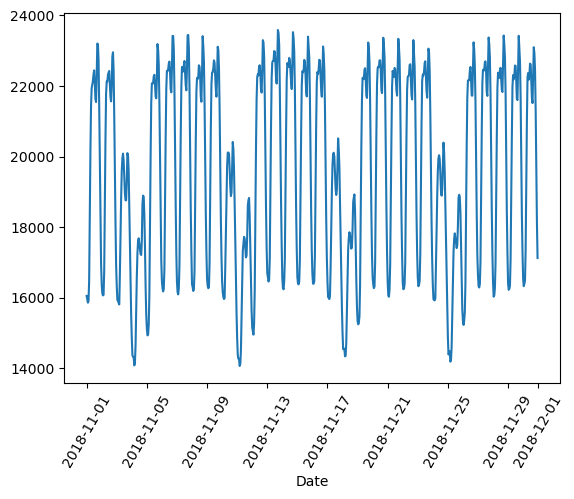

In [15]:
# Membuat plot
plt.plot(fcst_df['ds'], fcst_df['TimeGPT'])
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])
#plt.plot(trainData['utc_timestamp'], trainData['PL_load_actual_entsoe_transparency'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees


# Menampilkan plot
plt.show()

## Merge forecast n actual

In [16]:
# Convert the 'ds' column in both DataFrames to the same data type (datetime)
fcst_df['ds'] = pd.to_datetime(fcst_df['ds'])
validData['ds'] = pd.to_datetime(validData['ds'])

# Now merge the DataFrames
result = pd.merge(fcst_df, validData, on='ds', how='inner')

In [17]:
result

,ds,TimeGPT,actual
0,2018-11-01 00:00:00,16053.107,15637.0
1,2018-11-01 01:00:00,15948.902,15051.0
2,2018-11-01 02:00:00,15860.389,14659.0
3,2018-11-01 03:00:00,15902.477,14480.0
4,2018-11-01 04:00:00,16484.860,14534.0
...,...,...,...
715,2018-11-30 19:00:00,22441.178,25057.0
716,2018-11-30 20:00:00,21301.275,24284.0
717,2018-11-30 21:00:00,19628.332,22870.0
718,2018-11-30 22:00:00,18137.970,21467.0


## Metrics calculation (rRMSE and rMAE)

In [18]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['TimeGPT']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['TimeGPT'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)



rRMSE: 0.0979 rMAE: 0.0774 


## Comparison of GPT vs Actual

In [19]:
city = 'Hourly Poland TimeGPT'

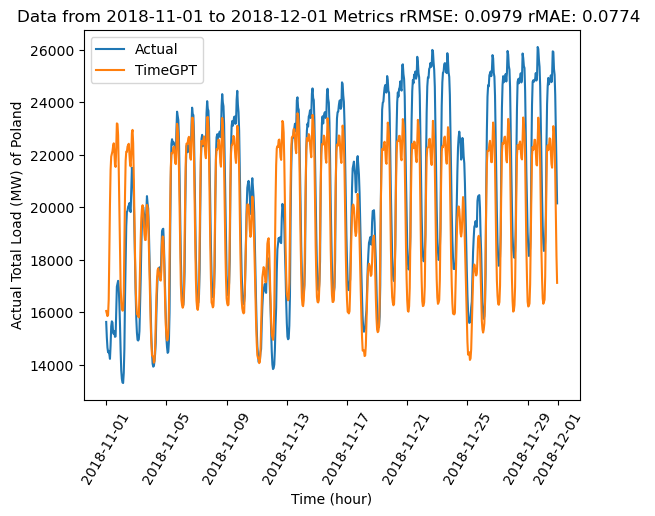

In [20]:
# plot Result dan save

plt.plot(result['ds'], result['actual'], label='Actual')
plt.plot(result['ds'], result['TimeGPT'],label='TimeGPT')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Time (hour)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of Poland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()


In [1]:
import pandas as pd

# Creating sample data
df1 = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['Alice', 'Bob', 'Charlie']})
df2 = pd.DataFrame({'ID': [1, 2, 4], 'Salary': [50000, 60000, 70000]})

# Merging on the 'ID' column
result = pd.merge(df1, df2, on='ID', how='inner')

In [2]:
result

,ID,Name,Salary
0,1,Alice,50000
1,2,Bob,60000
